#**RETAIL TOY STORE DATA ANALYSIS PROJECT**

#Business Understanding

##Latar Belakang
Industri retail mainan memiliki tantangan dalam mengelola:


*   Produk terlaris
*   Tren penjualan bulanan
*   Performa cabang toko
*   Tren penjualan bulanan

Melalui analisis data penjualan, perusahaaan dapat memahami perilaku penjualan dan mengambil keputusan bisnis dengan tepat.




##Tujuan Analisis


*   Mengidentifikasi produk & kategori terlaris
*   Mengetahui performa tiap cabang
*   Menganalisis profitabilitas
*   Memberikan rekomendasi bisnis

##Pertanyaan Bisnis


1.   Produk mana yang menghasilkan revenue terbesar?
2.   Cabang mana dengan performa terbaik?
3.   Bagaimana tren penjualan dari waktu ke waktu?
4.   Seberapa besar profit yang dihasilkan?

#Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

#Load Data

In [3]:
df = pd.read_csv('/content/drive/MyDrive/db/toys_sales.csv')

print("Data Shape", df.shape)

Data Shape (1000, 7)


In [4]:
print(df.head())

   order_date      product_name         category      branch_store  quantity  \
0  2024-10-08     Water Blaster      Outdoor Toy   Jakarta Central         4   
1  2025-03-08     Super Robot X    Action Figure      Medan Center         1   
2  2024-07-22  Math Puzzle Cube  Educational Toy      Medan Center        12   
3  2025-08-26          Baby Joy             Doll  Yogyakarta Plaza         5   
4  2024-10-11      Coding Robot  Educational Toy     Surabaya Mall         3   

   sales_value     profit  
0       144000   19423.37  
1        11000    1357.66  
2      1092000  300661.72  
3       555000  176115.42  
4       105000   35626.84  


#Data Understanding

In [5]:
print("\n===== DATA INFO =====")
print(df.info())

print("\n===== MISSING VALUE =====")
print(df.isna().sum())


===== DATA INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_date    1000 non-null   object 
 1   product_name  1000 non-null   object 
 2   category      1000 non-null   object 
 3   branch_store  1000 non-null   object 
 4   quantity      1000 non-null   int64  
 5   sales_value   1000 non-null   int64  
 6   profit        1000 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 54.8+ KB
None

===== MISSING VALUE =====
order_date      0
product_name    0
category        0
branch_store    0
quantity        0
sales_value     0
profit          0
dtype: int64


#Data Cleaning

In [6]:
#Hapus data duplikat
df.drop_duplicates(inplace=True)

#konversi date
df['order_date'] = pd.to_datetime(df['order_date'])

#cek missing values
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
order_date      0
product_name    0
category        0
branch_store    0
quantity        0
sales_value     0
profit          0
dtype: int64


#Feature Engineering
##1. KPI Analysis

In [7]:
#KPI Summary
total_sales = df['sales_value'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_date'].count()
item_sold = df['quantity'].sum()
avg_order_value = total_sales / total_orders
margin = (df['profit'] / df['sales_value']) * 100
avg_margin = margin.mean()


print("\n===== KPI SUMMARY =====")
print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Item Sold: {item_sold:,}")
print(f"Average Order Value: {avg_order_value:,.2f}")
print(f"Average Margin: {avg_margin:.2f}%")


===== KPI SUMMARY =====
Total Sales: 515,983,000.00
Total Profit: 114,960,790.98
Total Orders: 1,000
Item Sold: 8,050
Average Order Value: 515,983.00
Average Margin: 22.34%


##2. Monthly Sales Trend

In [8]:
#Monthly Sales Trend
df['month_year'] = df['order_date'].dt.to_period('M')

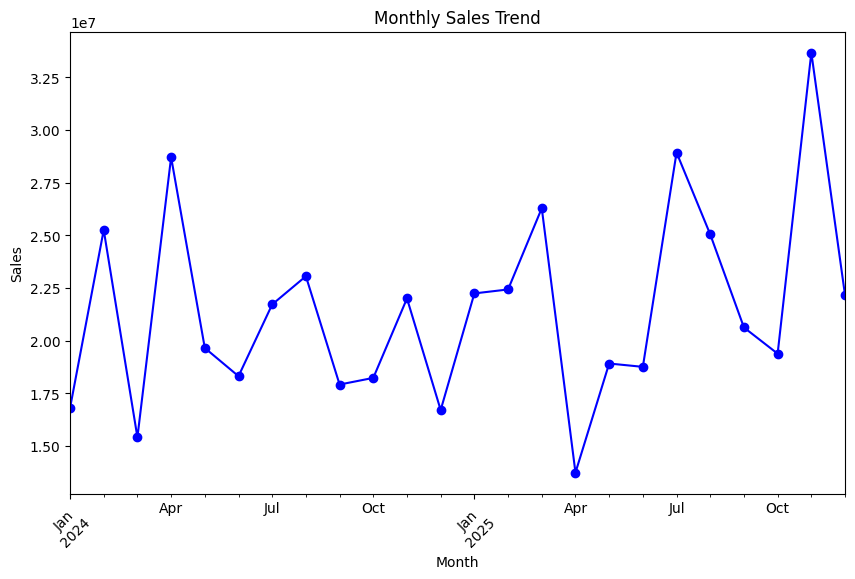

In [9]:
monthly_sales = df.groupby('month_year')['sales_value'].sum()

plt.figure(figsize=(10, 6))
monthly_sales.plot(kind='line', color='blue', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

###Insight:

Meskipun grafik menunjukkan fluktuasi yang tajam berulang, namun tren pertumbuhan bisnisnya cenderung positif per tahunnya.

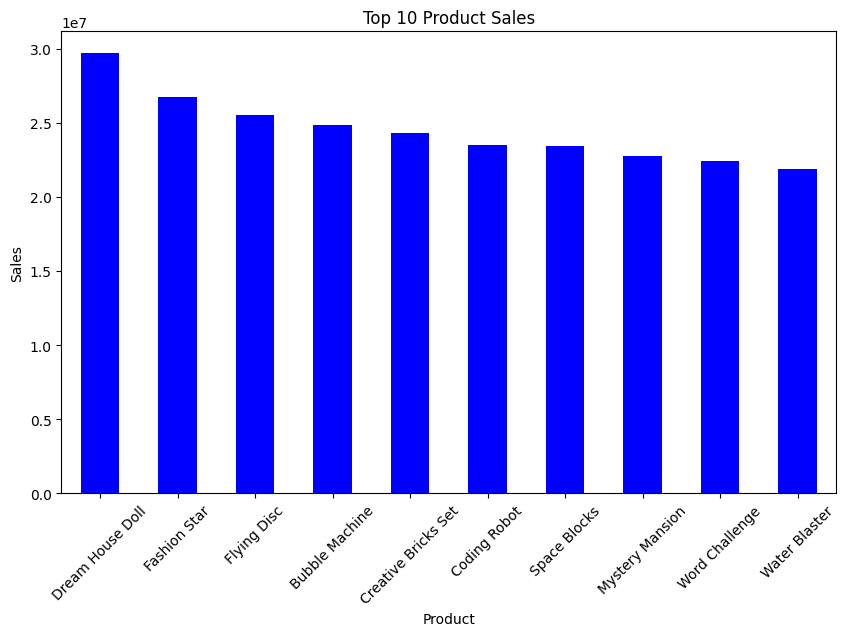

In [10]:
#Top Product Sales
top_product = df.groupby('product_name')['sales_value'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_product.plot(kind='bar', color='blue')
plt.title("Top 10 Product Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

###Insight:

Produk "Dream House Doll" menjadi produk dengan penjualan tertinggi.

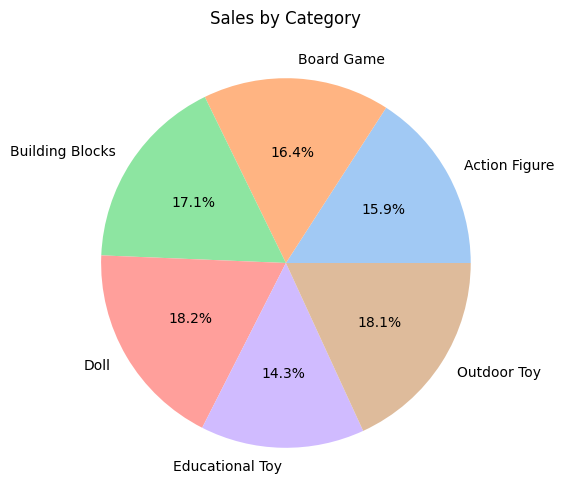

In [11]:
#Top Category
quantity = df.groupby('category')['sales_value'].sum()

plt.figure(figsize=(10, 6))
quantity.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title("Sales by Category")
plt.ylabel(" ")
plt.show()

###Insight:

Persentase penjualan per kategorinya cenderung merata. Sangat bagus untuk bisnis karena tidak hanya tergantung pada 1-2 kategori produk.

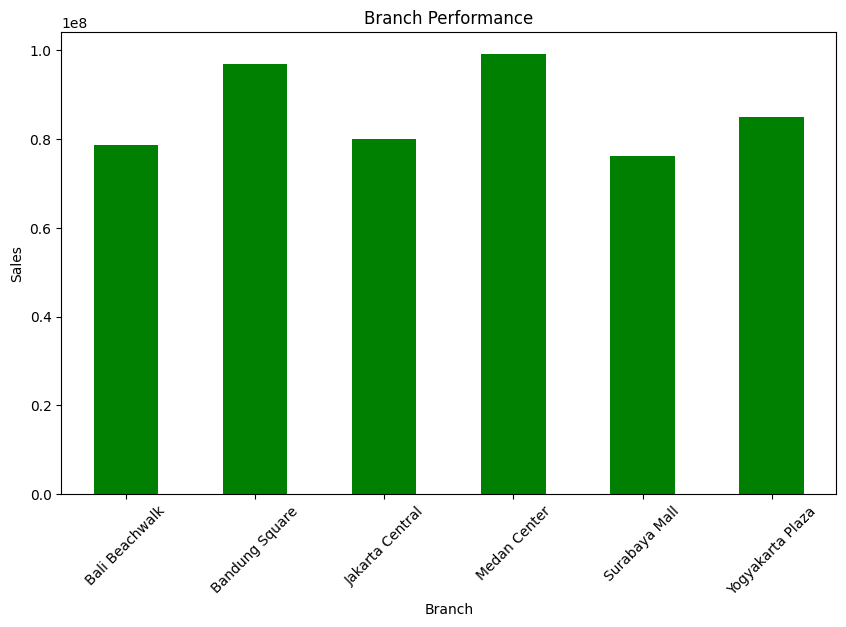

In [12]:
#Top Product Sales
branch = df.groupby('branch_store')['sales_value'].sum()

plt.figure(figsize=(10, 6))
branch.plot(kind='bar', color='green')
plt.title("Branch Performance")
plt.xlabel("Branch")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

###Insight:

Branch Medan Center menjadi toko cabang dengan penjualan tertinggi, disusul dengan Bandung Square.

### Sales vs. Profit Comparison for Top Products

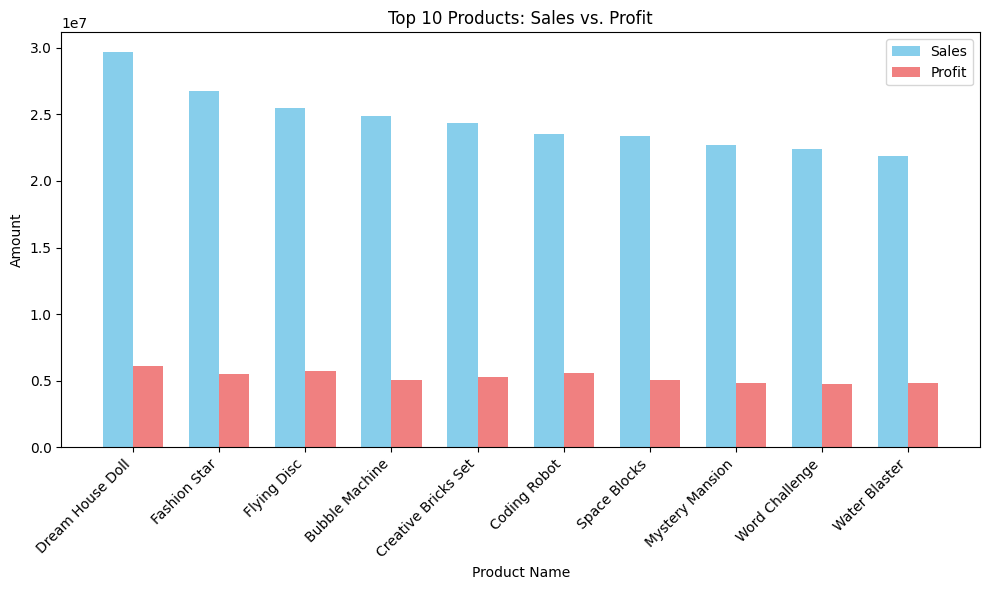

In [13]:
# Group by product name to get total sales and profit for each product
product_summary = df.groupby('product_name').agg(
    sales_value=('sales_value', 'sum'),
    profit=('profit', 'sum')
).sort_values(by='sales_value', ascending=False).head(10).reset_index()

# Set the positions for the bars
bar_width = 0.35
index = range(len(product_summary))

plt.figure(figsize=(10, 6))

# Plotting Sales bars
plt.bar(index, product_summary['sales_value'], bar_width, label='Sales', color='skyblue')

# Plotting Profit bars, slightly offset
plt.bar([i + bar_width for i in index], product_summary['profit'], bar_width, label='Profit', color='lightcoral')

plt.xlabel('Product Name')
plt.ylabel('Amount')
plt.title('Top 10 Products: Sales vs. Profit')
plt.xticks([i + bar_width / 2 for i in index], product_summary['product_name'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

###Insight:

Margin laba taip produk cenderung stabil, berkisar di antara 20% hingga 26%.

### Correlation Heatmap: Quantity, Sales, and Profit

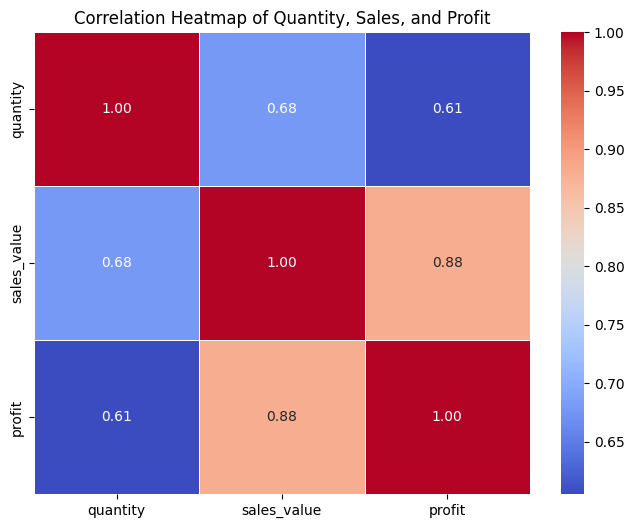

In [14]:
# Select the relevant columns for correlation
correlation_data = df[['quantity', 'sales_value', 'profit']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5
)
plt.title('Correlation Heatmap of Quantity, Sales, and Profit')
plt.show()

###Insight:

Penjualan dengan profit memiliki korelasi yang sangat kuat. Kuantitas produk yang terjual dengan penjualan serta profit memiliki korelasi menengah.


##Key Insight:


*   Memiliki profit margin ~22%, menunjukkan bahwa bisnis retail mainan ini sehat & menguntungkan.
*   Penjualan tidak bergantung pada kategori tertentu.



##Recommendations:


1.   Fokus pada produk best seller.
2.   Riset ke setiap store terkait strategi & kendala guna mengoptimasi penjualan di masa yang akan datang.


1.   Tingkatkan penjualan produk dengan profit margin tertinggi.








